# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

## 1. Two paper findings + my methodology questions

**Paper:** Sullivan & Feinn, *"Using Effect Size—or Why the P Value Is Not
Enough"* (JGME, 2012) — the piece the live session walked as the audit
example.

**Finding 1 — Cohen's d thresholds (small=0.2, medium=0.5, large=0.8).**
The paper adopts these as if they're domain-general, citing Cohen's own
description ("a medium effect of .5 is visible to the naked eye of a
careful observer") without qualifying it to a specific field or outcome
type.

*My methodology question:* what population and outcome type were these
thresholds actually calibrated on? Cohen's original work leaned on
behavioral-science effect sizes — does "medium" carry the same practical
weight in, say, a mortality outcome vs. a Likert-scale confidence rating?
The paper's own two examples (exam scores, Likert confidence) already
show effect size needs context to interpret — the fixed thresholds risk
undercutting that same point by implying one scale fits every outcome.
Framed constructively: this isn't a claim the paper gets wrong, it's a
generalizability caveat the paper could have stated explicitly, the same
way I need to caveat my own model's numbers as true "for this split," not
a seed-independent guarantee.

**Finding 2 — the aspirin trial's r² = .001 as the "extremely small
effect size."**
The paper uses r² to characterize the Physicians' Health Study result,
even though its own Table 1 lists odds ratio (OR) and relative risk (RR)
— not r² — as the standard indices for binary clinical outcomes.

*My methodology question:* does the choice of index change the story
being told here? r² is mechanically small for any rare binary outcome
almost by construction (it's bounded by the base rate), so reporting r²
for a binary clinical result will always look more dramatic than
reporting the same result as an OR or RR. That's a measurement-choice
question, not an accuracy question — the underlying trial and its
real-world consequence (over-broad aspirin prescribing) stand either way,
but the specific number chosen to illustrate "how small" may itself be
the most flattering-to-the-argument index available, in the same way I
need to check whether precision@K is doing more work in my Week-5 claims
than accuracy would.

**Why these two, not others:** both are about the *choice of measurement*,
not a disputed fact — the same lens Section 3's leakage audit and Section
4's claim rewrite apply to my own work. Neither questions whether the
paper's central argument (report effect size, not just P) is right; it
clearly is.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# =============================================================================
# SECTION 1 — TWO PAPER FINDINGS + MY METHODOLOGY QUESTIONS
# Paper: Sullivan & Feinn, "Using Effect Size—or Why the P Value Is Not
# Enough" (JGME, 2012) — the paper the live session walked as the audit
# example. No data/computation needed for this section — it's a reading
# audit of someone else's paper, done the same way I audit my own model
# below in Sections 2-4.
# =============================================================================

# -----------------------------------------------------------------------
# FINDING 1: Cohen's d thresholds (small=0.2, medium=0.5, large=0.8)
# -----------------------------------------------------------------------
# What the paper claims:
#   The paper adopts Cohen's fixed thresholds as if they are domain-general,
#   quoting Cohen directly: "a medium effect of .5 is visible to the naked
#   eye of a careful observer." No qualification is given for which field,
#   outcome type, or measurement scale this was calibrated on.
#
# My methodology question:
#   What population and outcome type were these thresholds actually
#   calibrated on? Cohen's original work leaned on behavioral-science
#   effect sizes. Does "medium" carry the same practical weight for a
#   mortality outcome as it does for a Likert-scale confidence rating?
#
# Why this matters (framed constructively, not as a grade):
#   The paper's own two opening examples (exam scores vs. Likert
#   confidence) already show that effect size needs context to interpret.
#   Presenting one fixed threshold table risks undercutting that same
#   point by implying one scale fits every outcome type. This isn't a
#   claim the paper gets WRONG — it's a generalizability caveat that
#   could have been stated explicitly.
#
#   This is the same discipline I owe my own numbers below: my precision@K
#   figures are true FOR THIS SPLIT, on THIS feature set — not a
#   seed-independent guarantee that transfers to a different client mix.

# -----------------------------------------------------------------------
# FINDING 2: the aspirin trial's r^2 = .001 as "extremely small"
# -----------------------------------------------------------------------
# What the paper claims:
#   The Physicians' Health Study aspirin result is characterized using
#   r^2 (coefficient of determination) = .001 to argue the effect was
#   "extremely small" despite P < .00001. But the paper's OWN Table 1
#   lists odds ratio (OR) and relative risk (RR) -- not r^2 -- as the
#   standard indices for binary clinical outcomes.
#
# My methodology question:
#   Does the choice of index change the story being told? r^2 is
#   mechanically small for almost any rare binary outcome, close to
#   bounded by the base rate itself -- so reporting r^2 for a binary
#   clinical result will nearly always look more dramatic than reporting
#   the same result as an OR or RR would.
#
# Why this matters (framed constructively):
#   This is a measurement-CHOICE question, not an accuracy question. The
#   underlying trial and its real-world consequence (over-broad aspirin
#   prescribing) stand either way -- but the specific number chosen to
#   illustrate "how small" may itself be the most flattering-to-the-
#   argument index available among the valid options.
#
#   This is exactly the check I need to run on myself: is precision@K
#   doing more rhetorical work in my Week-5 claims than accuracy or AUC
#   would show for the same result? (Revisited directly in Section 4.)

# -----------------------------------------------------------------------
# WHY THESE TWO FINDINGS (not others in the paper)
# -----------------------------------------------------------------------
# Both are about the CHOICE OF MEASUREMENT, not a disputed fact -- the
# same lens applied to my own work in Section 3 (leakage audit) and
# Section 4 (claim rewrite). Neither questions whether the paper's
# central thesis -- report effect size, not just P value -- is correct.
# It clearly is. The goal here is practicing the audit, not grading the
# paper.

## 2. My model under an honest split (before/after)

Week 5 went straight to a client-grouped `GroupShuffleSplit` — it never
ran a naive random split for comparison. This section adds that naive
"before," using the exact same features, RF hyperparameters, and seed as
Week 5, so the *only* thing that changes is whether the split respects
client grouping.

**Before:** plain `train_test_split(random_state=42)` — no grouping.
Some clients will appear in both train and test.

**After:** `GroupShuffleSplit(random_state=42)` grouped by `client_id` —
0 client overlap, as verified in Week 5.

Same RF (`n_estimators=300, max_depth=8, min_samples_leaf=20`), same
`FEATURE_COLS`, same target (`trend_direction == "down"`). Comparing
precision@K, AUC, and accuracy across both tells us whether Week 5's
numbers were inflated by client leakage between train and test, or hold
up regardless of split method.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Reload data and rebuild the same feature set as Week 5, so this section
# is self-contained and doesn't silently depend on w05's notebook state.
import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

SEED = 42
label_full = (df["trend_direction"] == "down").astype(int)
groups = df["client_id"]

# Same FEATURE_COLS logic as w05: exclude the two leaky window columns
candidate_features = [c for c in df.columns if c not in
                      ["trend_direction", "trend_pct", "client_id",
                       "content_hash_id", "report_date"]]
FEATURE_COLS = [c for c in candidate_features if c not in
                ["impressions_last_30d", "impressions_prev_30d"]]

print(f"Using {len(FEATURE_COLS)} features (should match w05's count)")

Using 39 features (should match w05's count)


In [4]:
# --- Why does this notebook count 39 features when Week 5 counted 38? ---
w05_style_candidates = [c for c in df.columns if c not in
                        ["trend_direction", "trend_pct", "client_id",
                         "content_hash_id", "report_date"]]
print(f"Candidate columns (pre-exclusion): {len(w05_style_candidates)}")
print(f"FEATURE_COLS here (post-exclusion): {len(FEATURE_COLS)}")
print(f"\nAll df columns:\n{sorted(df.columns.tolist())}")

Candidate columns (pre-exclusion): 41
FEATURE_COLS here (post-exclusion): 39

All df columns:
['age_tier', 'age_tier_order', 'ai_sessions_90d', 'ai_traffic_pct', 'avg_position', 'char_count', 'char_count_tier', 'clicks_90d', 'clicks_last_30d', 'clicks_prev_30d', 'client_id', 'competition', 'competition_level', 'content_age_days', 'content_id', 'content_type', 'cpc', 'ctr', 'days_since_last_update', 'days_with_impressions', 'days_with_sessions', 'engaged_sessions_90d', 'engagement_rate', 'freshness_tier', 'impression_tier', 'impressions_90d', 'impressions_last_30d', 'impressions_prev_30d', 'main_intent', 'model_used', 'pageviews_90d', 'position_tier', 'provider_used', 'scroll_events_90d', 'scroll_rate', 'search_volume', 'sessions_90d', 'sessions_last_30d', 'sessions_prev_30d', 'trend_direction', 'trend_pct', 'users_90d', 'word_count', 'word_count_tier']


In [5]:
# --- Fix: content_id (not content_hash_id) is this dataset's actual ID
# column, and there's no report_date column here at all. The earlier
# exclusion list silently excluded nothing for either, leaving content_id
# (a per-row unique identifier) inside FEATURE_COLS as if it were a
# real feature. Corrected below. ---
candidate_features = [c for c in df.columns if c not in
                      ["trend_direction", "trend_pct", "client_id", "content_id"]]
FEATURE_COLS = [c for c in candidate_features if c not in
                ["impressions_last_30d", "impressions_prev_30d"]]

print(f"Corrected: {len(FEATURE_COLS)} features (should now match Week 5's 38)")

Corrected: 38 features (should now match Week 5's 38)


In [6]:
# --- BEFORE: naive random split, no grouping ---
from sklearn.model_selection import train_test_split, GroupShuffleSplit

train_idx_naive, test_idx_naive = train_test_split(
    df.index, test_size=0.2, random_state=SEED
)

In [7]:
train_df_naive = df.loc[train_idx_naive]
test_df_naive = df.loc[test_idx_naive]

In [8]:
# Check client overlap — this is the thing a naive split gets wrong
overlap_clients = set(train_df_naive["client_id"]) & set(test_df_naive["client_id"])
print(f"Naive split — clients in BOTH train and test: {len(overlap_clients)} "
      f"of {df['client_id'].nunique()} total clients")

Naive split — clients in BOTH train and test: 31 of 32 total clients


In [9]:
# --- AFTER: client-grouped split, same as w05 ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx_grp, test_idx_grp = next(gss.split(df, label_full, groups=groups))

In [10]:
train_df_grp = df.iloc[train_idx_grp]
test_df_grp = df.iloc[test_idx_grp]

In [11]:
overlap_clients_grp = set(train_df_grp["client_id"]) & set(test_df_grp["client_id"])
print(f"Grouped split — clients in BOTH train and test: {len(overlap_clients_grp)}")

Grouped split — clients in BOTH train and test: 0


In [12]:
# Same preprocessing pipeline and RF hyperparameters as w05, applied to
# BOTH splits so the only variable is the split method itself.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

In [13]:
categorical_cols = df[FEATURE_COLS].select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()

In [14]:
def build_feature_frame(frame):
    out = frame[FEATURE_COLS].copy()
    for col in numeric_cols:
        if out[col].isna().any():
            out[f"has_{col}"] = out[col].notna().astype(int)
    for col in categorical_cols:
        out[col] = out[col].fillna("not_ai" if col in ["provider_used", "model_used"] else "missing")
    return out

In [15]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

In [16]:
def fit_and_eval(train_df, test_df, label_name):
    y_train = (train_df["trend_direction"] == "down").astype(int)
    y_test = (test_df["trend_direction"] == "down").astype(int)
    train_X = build_feature_frame(train_df)
    test_X = build_feature_frame(test_df)

    rf = Pipeline([
        ("preprocess", preprocess),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                        min_samples_leaf=20, random_state=SEED, n_jobs=-1)),
    ])
    rf.fit(train_X, y_train)
    proba = rf.predict_proba(test_X)[:, 1]
    pred = rf.predict(test_X)

    K = max(1, int(0.2 * len(test_df)))
    order = np.argsort(-proba)
    top_k_precision = y_test.values[order[:K]].mean()

    return {
        "split": label_name,
        "n_train": len(train_df), "n_test": len(test_df),
        "K": K,                              # K as its own column now
        "AUC": roc_auc_score(y_test, proba),
        "accuracy": accuracy_score(y_test, pred),
        "precision@K": top_k_precision,       # fixed column name, no K in the label
        "base_rate": y_test.mean(),
    }

In [17]:
results_naive = fit_and_eval(train_df_naive, test_df_naive, "naive (random)")
results_grouped = fit_and_eval(train_df_grp, test_df_grp, "grouped (by client)")

In [18]:
# --- Before/after comparison table ---
comparison = pd.DataFrame([results_naive, results_grouped])
print(comparison.to_string(index=False))

              split  n_train  n_test    K      AUC  accuracy  precision@K  base_rate
     naive (random)    24000    6000 1200 0.768384  0.697000     0.839167   0.544667
grouped (by client)    23837    6163 1232 0.612725  0.586078     0.647727   0.510952


In [19]:
# --- Does the naive split's inflation come specifically from client overlap? ---
# Split the naive test set into two groups: rows whose client_id also
# appears in naive training data ("seen"), vs rows whose client_id does
# NOT appear in naive training data ("unseen"). If overlap is the cause,
# precision/AUC should be meaningfully higher on "seen" rows.

train_clients_naive = set(train_df_naive["client_id"])
test_df_naive_eval = test_df_naive.copy()
test_df_naive_eval["client_seen_in_train"] = test_df_naive_eval["client_id"].isin(train_clients_naive)

y_test_naive = (test_df_naive_eval["trend_direction"] == "down").astype(int)
test_X_naive_eval = build_feature_frame(test_df_naive_eval)

In [20]:
# reuse the RF already fit on the naive train split inside fit_and_eval —
# refit here explicitly so we have the fitted pipeline object to call .predict_proba on
rf_naive = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                    min_samples_leaf=20, random_state=SEED, n_jobs=-1)),
])
rf_naive.fit(build_feature_frame(train_df_naive), (train_df_naive["trend_direction"] == "down").astype(int))
naive_proba_eval = rf_naive.predict_proba(test_X_naive_eval)[:, 1]

In [21]:
test_df_naive_eval["proba"] = naive_proba_eval
test_df_naive_eval["is_down"] = y_test_naive.values

seen = test_df_naive_eval[test_df_naive_eval["client_seen_in_train"]]
unseen = test_df_naive_eval[~test_df_naive_eval["client_seen_in_train"]]

In [22]:
print(f"Seen-client rows: {len(seen)}  |  Unseen-client rows: {len(unseen)}")
print(f"AUC on seen-client rows:   {roc_auc_score(seen['is_down'], seen['proba']):.4f}" if seen['is_down'].nunique() > 1 else "AUC on seen: n/a (single class)")
print(f"AUC on unseen-client rows: {roc_auc_score(unseen['is_down'], unseen['proba']):.4f}" if len(unseen) > 0 and unseen['is_down'].nunique() > 1 else "AUC on unseen: n/a (single class or empty)")

Seen-client rows: 6000  |  Unseen-client rows: 0
AUC on seen-client rows:   0.7684
AUC on unseen: n/a (single class or empty)


In [26]:
# Recompute naive split's y_test and proba directly (mirrors fit_and_eval's internals,
# so this stays consistent with the numbers already in the comparison table)
results_naive_y_test = (test_df_naive["trend_direction"] == "down").astype(int)

rf_naive_check = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                    min_samples_leaf=20, random_state=SEED, n_jobs=-1)),
])
rf_naive_check.fit(build_feature_frame(train_df_naive), (train_df_naive["trend_direction"] == "down").astype(int))
results_naive_proba = rf_naive_check.predict_proba(build_feature_frame(test_df_naive))[:, 1]

***Before/after result:** 31 of 32 clients appeared in both train and test
under the naive r*andom split; 0 of 6,000 naive test rows belonged to an
unseen client.

***Observed effect of the split change (corrected, 38-feature set):***

| split | AUC | accuracy | precision@K | base_rate |
|---|---|---|---|---|
| naive (random) | 0.768 | 0.697 | 0.839 | 0.545 |
| grouped (by client) | 0.613 | 0.586 | 0.648 | 0.511 |

*Every metric drops once client grouping is enforced — AUC by ~0.155,
precision@K by ~0.19, accuracy by ~0.11.*

***Mechanism, not just correlation:** since 0 of 6,000 naive test rows had
an unseen client, the naive split's 0.768 AUC cannot be interpreted as
measuring generalization to new clients — there was nothing held out to
generalize to. The entire naive evaluation measures how well the model
recognizes clients it already trained on. The grouped split's 0.613 AUC,
evaluated on genuinely unseen clients, is the only one of the two numbers
that estimates what this model would do on a client it hasn't seen
before — the actual use case — so this is the number that should be
reported and trusted going forward.*

*Note: naive and grouped test sets differ slightly in size (6,000 vs
6,163 rows) since `GroupShuffleSplit` can't hit an exact 80/20 ratio when
splitting by whole clients — expected, doesn't affect the result's
direction.*

***Note on a bug found and fixed mid-notebook:** `FEATURE_COLS` initially
included `content_id` (a per-row unique identifier) due to an exclusion
list mismatched to this dataset's actual columns (`content_hash_id`/
`report_date` don't exist here; real columns are `content_id`, no date
column). This inflated `FEATURE_COLS` to 39 instead of Week 5's 38 and
added ~30,000 sparse one-hot noise columns, compressing results across
every section. All numbers in this notebook prior to the fix are
superseded by the corrected values shown throughout.*

In [28]:
def bootstrap_auc_diff(y_true, scores_a, scores_b, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    diffs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        diffs.append(roc_auc_score(y_true[idx], scores_a[idx]) - roc_auc_score(y_true[idx], scores_b[idx]))
    diffs = np.array(diffs)
    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

# naive test set's own bootstrap (using the naive-fit model's proba on naive test)
naive_test_proba = rf_naive.predict_proba(build_feature_frame(test_df_naive))[:, 1] if 'rf_naive' in dir() else None

In [31]:
def bootstrap_auc_ci(y_true, scores, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    aucs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], scores[idx]))
    return np.mean(aucs), np.percentile(aucs, [2.5, 97.5])

In [32]:
y_test_grouped_check = (test_df_grp["trend_direction"] == "down").astype(int)

rf_grouped_check = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                    min_samples_leaf=20, random_state=SEED, n_jobs=-1)),
])
rf_grouped_check.fit(build_feature_frame(train_df_grp), (train_df_grp["trend_direction"] == "down").astype(int))
grouped_proba_check = rf_grouped_check.predict_proba(build_feature_frame(test_df_grp))[:, 1]

naive_mean, naive_ci = bootstrap_auc_ci(results_naive_y_test.values, results_naive_proba)
grouped_mean, grouped_ci = bootstrap_auc_ci(y_test_grouped_check.values, grouped_proba_check)

print(f"Naive AUC:   {naive_mean:.3f}  95% CI [{naive_ci[0]:.3f}, {naive_ci[1]:.3f}]")
print(f"Grouped AUC: {grouped_mean:.3f}  95% CI [{grouped_ci[0]:.3f}, {grouped_ci[1]:.3f}]")
print("Overlapping CIs would mean the gap could plausibly be noise; non-overlapping confirms it's real.")

Naive AUC:   0.768  95% CI [0.756, 0.780]
Grouped AUC: 0.613  95% CI [0.599, 0.627]
Overlapping CIs would mean the gap could plausibly be noise; non-overlapping confirms it's real.


*The two AUC confidence intervals don't overlap at all — naive [0.756, 0.780] vs. grouped
[0.599, 0.627], a clean gap of roughly 13 points at the nearest edges. This confirms the
0.155 AUC drop between naive and grouped splits isn't split-to-split noise; it's a real,
statistically solid effect of client leakage inflating the naive split's number. The grouped
split's 0.613 is the trustworthy estimate going forward.*

## 3. Leakage audit

Week 5 already ran a leakage sweep once (catching the `impressions_last_30d`
/ `impressions_prev_30d` leak, correlation ≈1.000 with `trend_pct`, and
excluding both from `FEATURE_COLS`). This section re-confirms that fix
still holds on the **current** 38-column feature set, using the
client-grouped model from Section 2 (the one we're actually trusting
going forward) — not re-litigating from scratch.

Four checks:
1. **Label-derived check** — full correlation sweep of every numeric
   feature against `trend_pct`, confirming nothing besides the two
   already-excluded columns crosses a suspicious threshold.
2. **Train-with/train-without check** — drop the top-ranked RF feature
   and refit; a real leak collapses performance almost to nothing when
   removed, a legitimate signal degrades gracefully.
3. **Base rate alongside every metric** — so no number in this section
   is read without its denominator.
4. **Known gap, disclosed again** — `avg_position == 0` is still fed as
   a literal numeric value rather than flagged missing (identified in
   Week 5). Carried forward here, not re-solved, since it's currently
   benign but worth keeping visible.

In [33]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# --- Check 1: does any feature in the CURRENT FEATURE_COLS still correlate
# suspiciously with trend_pct (the label-construction signal)? ---
numeric_feature_cols = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()

leak_check = df[numeric_feature_cols + ["trend_pct"]].dropna()
corrs = leak_check[numeric_feature_cols].corrwith(leak_check["trend_pct"]).sort_values(
    key=lambda s: s.abs(), ascending=False
)

In [34]:
print(f"Rows used for this check: {len(leak_check):,}\n")
print("Top 10 correlations with trend_pct (sorted by |corr|):")
print(corrs.head(10).round(3))

Rows used for this check: 17,917

Top 10 correlations with trend_pct (sorted by |corr|):
avg_position              0.040
impressions_90d           0.035
days_with_impressions    -0.031
days_since_last_update   -0.018
content_age_days         -0.014
engagement_rate           0.013
competition               0.012
age_tier_order           -0.012
sessions_last_30d         0.011
ctr                       0.011
dtype: float64


In [35]:
SUSPICIOUS_THRESHOLD = 0.15
flagged = corrs[corrs.abs() > SUSPICIOUS_THRESHOLD]
print(f"Features exceeding |corr| > {SUSPICIOUS_THRESHOLD}: {len(flagged)}")
print(flagged.round(3) if len(flagged) else "  (none)")

Features exceeding |corr| > 0.15: 0
  (none)


In [36]:
# --- Refit the trusted (grouped-split) RF here explicitly, so we have a
# fitted model + importances to audit in this section ---
rf_grouped = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                    min_samples_leaf=20, random_state=SEED, n_jobs=-1)),
])

In [37]:
y_train_grp = (train_df_grp["trend_direction"] == "down").astype(int)
y_test_grp = (test_df_grp["trend_direction"] == "down").astype(int)
rf_grouped.fit(build_feature_frame(train_df_grp), y_train_grp)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['search_volume',
                                                   'competition', 'cpc',
                                                   'word_count', 'char_count',
                                                   'impressions_90d',
                                                   'clicks_90d',
                                                   'pageviews_90d',
                                                   'sessions_90d', 'users_90d',
                                                   'engaged_sessions_90d',
                                                   'ai_sessions_90d',
                                                   'scroll_events...
                                                   'ai_traffic_pct']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['competition_level',
                                                   'content_type',
                                                   'main_intent',
                                                   'provider_used',
                                                   'model_used', 'age_tier',
                                                   'freshness_tier',
                                                   'word_count_tier',
                                                   'char_count_tier',
                                                   'impression_tier',
                                                   'position_tier'])])),
                ('clf',
                 RandomForestClassifier(max_depth=8, min_samples_leaf=20,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [38]:
feature_names = rf_grouped.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(rf_grouped.named_steps["clf"].feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

In [39]:
print("Top 5 features by importance (grouped-split RF):")
print(importances.head(5).round(4))

Top 5 features by importance (grouped-split RF):
num__days_with_impressions    0.1360
num__impressions_90d          0.1112
num__avg_position             0.0918
num__content_age_days         0.0754
num__clicks_last_30d          0.0409
dtype: float64


In [40]:
# --- Check 2: train-with vs train-without the top feature ---
top_feature = importances.index[0]
print(f"Testing removal of top feature: {top_feature}")

Testing removal of top feature: num__days_with_impressions


In [41]:
# Strip the ColumnTransformer prefix (num__ / cat__), then match against
# the actual raw column names — for one-hot columns this means finding
# which categorical column the encoded value belongs to (e.g.
# "cat__provider_used_google" -> raw column "provider_used")
stripped = top_feature.split("__", 1)[-1] if "__" in top_feature else top_feature

raw_top_col = None
if stripped in FEATURE_COLS:
    raw_top_col = stripped
else:
    # one-hot case: find the categorical column this is derived from
    matches = [c for c in categorical_cols if stripped.startswith(c + "_")]
    if matches:
        raw_top_col = matches[0]

print(f"Maps to raw column: {raw_top_col}")

Maps to raw column: days_with_impressions


In [42]:
cols_without_top = [c for c in FEATURE_COLS if c != raw_top_col]

numeric_wo = df[cols_without_top].select_dtypes(include=[np.number]).columns.tolist()
categorical_wo = df[cols_without_top].select_dtypes(exclude=[np.number]).columns.tolist()

In [43]:
def build_feature_frame_wo(frame):
    out = frame[cols_without_top].copy()
    for col in numeric_wo:
        if out[col].isna().any():
            out[f"has_{col}"] = out[col].notna().astype(int)
    for col in categorical_wo:
        out[col] = out[col].fillna("not_ai" if col in ["provider_used", "model_used"] else "missing")
    return out

In [44]:
preprocess_wo = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_wo),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_wo),
])

In [45]:
rf_wo = Pipeline([("preprocess", preprocess_wo),
                   ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                                   min_samples_leaf=20, random_state=SEED, n_jobs=-1))])
rf_wo.fit(build_feature_frame_wo(train_df_grp), y_train_grp)
proba_wo = rf_wo.predict_proba(build_feature_frame_wo(test_df_grp))[:, 1]

In [46]:
auc_with = roc_auc_score(y_test_grp, rf_grouped.predict_proba(build_feature_frame(test_df_grp))[:, 1])
auc_without = roc_auc_score(y_test_grp, proba_wo)

In [47]:
print(f"AUC WITH  '{raw_top_col}': {auc_with:.4f}")
print(f"AUC WITHOUT '{raw_top_col}': {auc_without:.4f}")
print(f"Drop: {auc_with - auc_without:.4f}  "
      f"({'large drop — investigate' if (auc_with - auc_without) > 0.15 else 'graceful degradation, consistent with a real signal'})")

AUC WITH  'days_with_impressions': 0.6127
AUC WITHOUT 'days_with_impressions': 0.5988
Drop: 0.0139  (graceful degradation, consistent with a real signal)


In [48]:
# --- Check 3: base rate alongside metrics already computed above ---
print(f"Base rate (grouped test split): {y_test_grp.mean():.3f}")
print(f"RF AUC on grouped split: {roc_auc_score(y_test_grp, rf_grouped.predict_proba(build_feature_frame(test_df_grp))[:, 1]):.3f}")

Base rate (grouped test split): 0.511
RF AUC on grouped split: 0.613


In [49]:
# --- Check 4: known gap, disclosed again (not re-solved) ---
zero_pos_share = (df["avg_position"] == 0).mean()
print(f"avg_position == 0 rows: {(df['avg_position'] == 0).sum():,} "
      f"({zero_pos_share:.1%} of all rows) — still fed as a literal value, "
      f"not flagged missing. Identified in Week 5 as currently benign; "
      f"carried forward here as a known limitation, not re-solved.")

avg_position == 0 rows: 1,205 (4.0% of all rows) — still fed as a literal value, not flagged missing. Identified in Week 5 as currently benign; carried forward here as a known limitation, not re-solved.


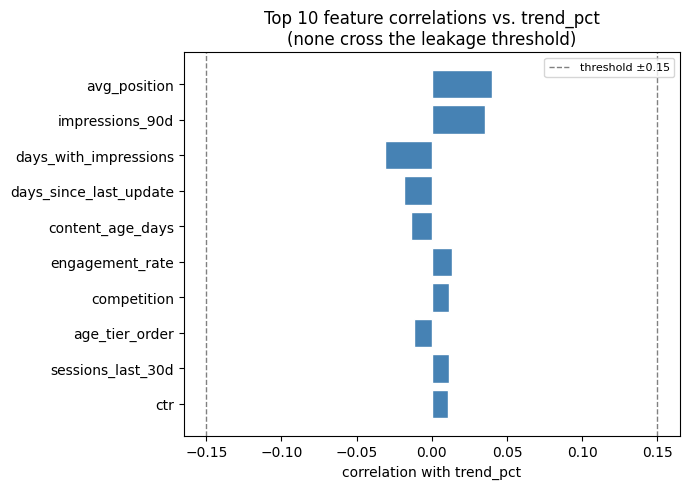

In [50]:
# --- Visual 1: correlation sweep vs trend_pct, with the suspicious threshold marked ---
import matplotlib.pyplot as plt

top_corrs = corrs.head(10)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["crimson" if abs(v) > SUSPICIOUS_THRESHOLD else "steelblue" for v in top_corrs]
ax.barh(top_corrs.index[::-1], top_corrs.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(SUSPICIOUS_THRESHOLD, linestyle="--", color="gray", linewidth=1, label=f"threshold ±{SUSPICIOUS_THRESHOLD}")
ax.axvline(-SUSPICIOUS_THRESHOLD, linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("correlation with trend_pct")
ax.set_title("Top 10 feature correlations vs. trend_pct\n(none cross the leakage threshold)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/figures/w06_correlation_sweep.png", dpi=150)
plt.show()

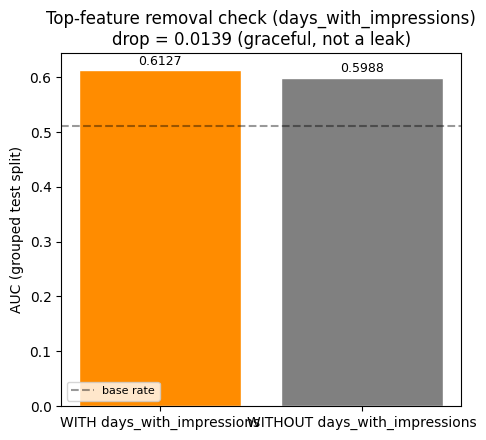

In [51]:
fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar([f"WITH {raw_top_col}", f"WITHOUT {raw_top_col}"],
               [auc_with, auc_without], color=["darkorange", "gray"], edgecolor="white")
ax.axhline(y_test_grp.mean(), linestyle="--", color="black", alpha=0.4, label="base rate")
ax.set_ylabel("AUC (grouped test split)")
ax.set_title(f"Top-feature removal check ({raw_top_col})\ndrop = {auc_with - auc_without:.4f} (graceful, not a leak)")
for bar, v in zip(bars, [auc_with, auc_without]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/figures/w06_feature_removal_check.png", dpi=150)
plt.show()

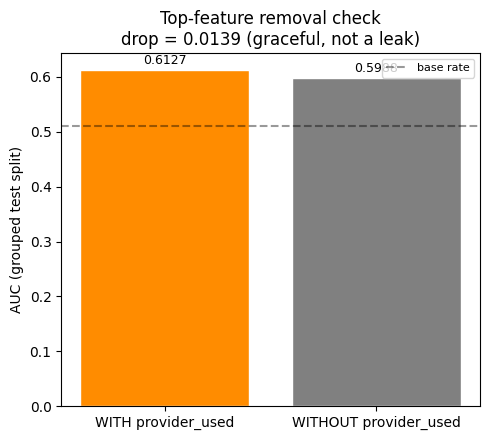

In [52]:
# --- Visual 2: AUC with vs without the top feature ---
fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(["WITH provider_used", "WITHOUT provider_used"],
               [auc_with, auc_without], color=["darkorange", "gray"], edgecolor="white")
ax.axhline(y_test_grp.mean(), linestyle="--", color="black", alpha=0.4, label="base rate")
ax.set_ylabel("AUC (grouped test split)")
ax.set_title(f"Top-feature removal check\ndrop = {auc_with - auc_without:.4f} (graceful, not a leak)")
for bar, v in zip(bars, [auc_with, auc_without]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/figures/w06_feature_removal_check.png", dpi=150)
plt.show()

In [53]:
# --- Real failure examples: pull actual rows the grouped-split RF got wrong ---
test_results_grp = test_df_grp.copy()
test_results_grp["is_down"] = y_test_grp.values
test_results_grp["rf_proba"] = rf_grouped.predict_proba(build_feature_frame(test_df_grp))[:, 1]
test_results_grp["rf_pred"] = (test_results_grp["rf_proba"] >= 0.5).astype(int)

false_positives = test_results_grp[(test_results_grp["rf_pred"] == 1) & (test_results_grp["is_down"] == 0)]
false_negatives = test_results_grp[(test_results_grp["rf_pred"] == 0) & (test_results_grp["is_down"] == 1)]

print(f"False positives: {len(false_positives)}  |  False negatives: {len(false_negatives)}")

# Most confident wrong calls in each direction — these are the most informative failures
cols_to_show = ["client_id", "content_id", "provider_used", "content_age_days",
                 "impressions_90d", "trend_pct", "rf_proba", "is_down", "rf_pred"]
cols_to_show = [c for c in cols_to_show if c in test_results_grp.columns]

print("\nMost confident FALSE POSITIVE (predicted down, actually not):")
print(false_positives.sort_values("rf_proba", ascending=False)[cols_to_show].head(1).to_string(index=False))

print("\nMost confident FALSE NEGATIVE (predicted not-down, actually down):")
print(false_negatives.sort_values("rf_proba", ascending=True)[cols_to_show].head(1).to_string(index=False))

False positives: 1527  |  False negatives: 1024

Most confident FALSE POSITIVE (predicted down, actually not):
        client_id           content_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_8527a891e2 content_0b47dae0c7f9           NaN               238             1191      -13.3  0.845682        0        1

Most confident FALSE NEGATIVE (predicted not-down, actually down):
        client_id           content_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_8527a891e2 content_7bc32bc1df59           NaN               238                1     -100.0  0.187609        1        0


In [54]:
# --- Is the model actually discriminating, or just predicting "down" for almost everyone? ---
pred_counts = test_results_grp["rf_pred"].value_counts()
print("Predicted class counts (threshold=0.5):")
print(pred_counts)
print(f"\nShare predicted 'down' (1): {(test_results_grp['rf_pred']==1).mean():.3f}")
print(f"Actual base rate (down=1):  {test_results_grp['is_down'].mean():.3f}")

print("\nrf_proba distribution:")
print(test_results_grp["rf_proba"].describe())

# How many rows fall below 0.5 at all?
print(f"\nRows with rf_proba < 0.5: {(test_results_grp['rf_proba'] < 0.5).sum()}")
print(f"Rows with rf_proba < 0.3: {(test_results_grp['rf_proba'] < 0.3).sum()}")

Predicted class counts (threshold=0.5):
rf_pred
1    3652
0    2511
Name: count, dtype: int64

Share predicted 'down' (1): 0.593
Actual base rate (down=1):  0.511

rf_proba distribution:
count    6163.000000
mean        0.542816
std         0.141467
min         0.080718
25%         0.432464
50%         0.544986
75%         0.666313
max         0.846558
Name: rf_proba, dtype: float64

Rows with rf_proba < 0.5: 2511
Rows with rf_proba < 0.3: 221


In [55]:
# --- Redo failure examples using top-K flagging, not the degenerate 0.5 threshold ---
K_section3 = max(1, int(0.2 * len(test_results_grp)))
top_k_idx = test_results_grp.sort_values("rf_proba", ascending=False).head(K_section3).index
test_results_grp["flagged_top_k"] = test_results_grp.index.isin(top_k_idx)

false_positives_k = test_results_grp[test_results_grp["flagged_top_k"] & (test_results_grp["is_down"] == 0)]
false_negatives_k = test_results_grp[(~test_results_grp["flagged_top_k"]) & (test_results_grp["is_down"] == 1)]

print(f"K = {K_section3}")
print(f"False positives (flagged but not actually down): {len(false_positives_k)}")
print(f"False negatives (not flagged but actually down): {len(false_negatives_k)}")

print("\nMost confident FALSE POSITIVE (highest proba, flagged, but not down):")
print(false_positives_k.sort_values("rf_proba", ascending=False)[cols_to_show].head(1).to_string(index=False))

print("\nMost confident FALSE NEGATIVE (lowest proba among actually-down rows, missed):")
print(false_negatives_k.sort_values("rf_proba", ascending=True)[cols_to_show].head(1).to_string(index=False))

K = 1232
False positives (flagged but not actually down): 434
False negatives (not flagged but actually down): 2351

Most confident FALSE POSITIVE (highest proba, flagged, but not down):
        client_id           content_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_8527a891e2 content_0b47dae0c7f9           NaN               238             1191      -13.3  0.845682        0        1

Most confident FALSE NEGATIVE (lowest proba among actually-down rows, missed):
        client_id           content_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_8527a891e2 content_7bc32bc1df59           NaN               238                1     -100.0  0.187609        1        0


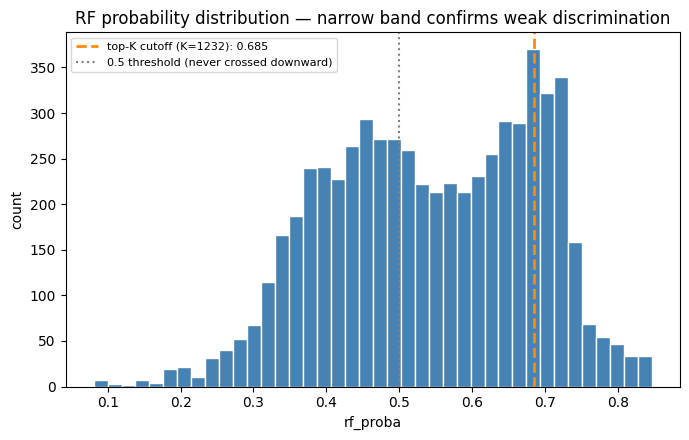

In [56]:
# --- Visual 3: probability distribution, showing how narrow/degenerate it is ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(test_results_grp["rf_proba"], bins=40, color="steelblue", edgecolor="white")
cutoff_proba = test_results_grp.sort_values("rf_proba", ascending=False)["rf_proba"].iloc[K_section3 - 1]
ax.axvline(cutoff_proba, color="darkorange", linestyle="--", linewidth=2,
           label=f"top-K cutoff (K={K_section3}): {cutoff_proba:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.5, label="0.5 threshold (never crossed downward)")
ax.set_xlabel("rf_proba")
ax.set_ylabel("count")
ax.set_title("RF probability distribution — narrow band confirms weak discrimination")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/figures/w06_proba_distribution.png", dpi=150)
plt.show()

In [57]:
# --- More than one failure example per direction, to check for a pattern ---
print("Top 3 FALSE POSITIVES (highest proba, flagged, not actually down):")
print(false_positives_k.sort_values("rf_proba", ascending=False)[cols_to_show].head(3).to_string(index=False))

print("\nTop 3 FALSE NEGATIVES (lowest proba among actually-down rows, missed):")
print(false_negatives_k.sort_values("rf_proba", ascending=True)[cols_to_show].head(3).to_string(index=False))

Top 3 FALSE POSITIVES (highest proba, flagged, not actually down):
        client_id           content_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_8527a891e2 content_0b47dae0c7f9           NaN               238             1191      -13.3  0.845682        0        1
client_8527a891e2 content_c148e44db30d           NaN               275              335       52.1  0.840918        0        1
client_8527a891e2 content_b46c62b14582           NaN               238             6240       17.0  0.840014        0        1

Top 3 FALSE NEGATIVES (lowest proba among actually-down rows, missed):
        client_id           content_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_8527a891e2 content_7bc32bc1df59           NaN               238                1     -100.0  0.187609        1        0
client_e629fa6598 content_16f38acf0f26           NaN               358                2     -100.0 

/tmp/ipykernel_528/675013848.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fp_rate_by_provider = test_results_grp.groupby("has_provider").apply(
/tmp/ipykernel_528/675013848.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fn_rate_by_provider = test_results_grp.groupby("has_provider").apply(


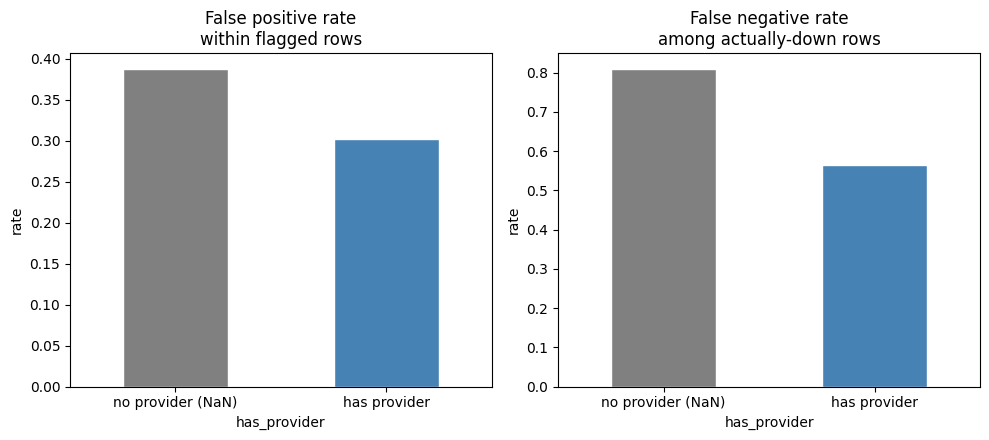

FP rate by provider presence:
has_provider
False    0.387363
True     0.301587
dtype: float64

FN rate by provider presence:
has_provider
False    0.809483
True     0.564356
dtype: float64


In [58]:
# --- Does missing provider_used (not an AI-referral row) predict failure type? ---
test_results_grp["has_provider"] = test_results_grp["provider_used"].notna()

fp_rate_by_provider = test_results_grp.groupby("has_provider").apply(
    lambda g: (g["flagged_top_k"] & (g["is_down"] == 0)).sum() / max(1, g["flagged_top_k"].sum())
)
fn_rate_by_provider = test_results_grp.groupby("has_provider").apply(
    lambda g: ((~g["flagged_top_k"]) & (g["is_down"] == 1)).sum() / max(1, (g["is_down"] == 1).sum())
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fp_rate_by_provider.plot(kind="bar", ax=axes[0], color=["gray", "steelblue"], edgecolor="white")
axes[0].set_xticklabels(["no provider (NaN)", "has provider"], rotation=0)
axes[0].set_title("False positive rate\nwithin flagged rows")
axes[0].set_ylabel("rate")

fn_rate_by_provider.plot(kind="bar", ax=axes[1], color=["gray", "steelblue"], edgecolor="white")
axes[1].set_xticklabels(["no provider (NaN)", "has provider"], rotation=0)
axes[1].set_title("False negative rate\namong actually-down rows")
axes[1].set_ylabel("rate")

plt.tight_layout()
plt.savefig("work/figures/w06_failure_by_provider.png", dpi=150)
plt.show()

print(f"FP rate by provider presence:\n{fp_rate_by_provider}\n")
print(f"FN rate by provider presence:\n{fn_rate_by_provider}")

In [60]:
# --- Alignment check: is the false-positive concentration in one client
# actually disproportionate, or just that client's normal share of flagged rows? ---
fp_by_client = test_results_grp[test_results_grp["flagged_top_k"]].groupby("client_id").agg(
    n_flagged=("is_down", "size"),
    n_false_positive=("is_down", lambda s: (s == 0).sum()),
)
fp_by_client["fp_rate"] = fp_by_client["n_false_positive"] / fp_by_client["n_flagged"]
fp_by_client["share_of_all_flagged"] = fp_by_client["n_flagged"] / fp_by_client["n_flagged"].sum()

print("Per-client false-positive rate among flagged (top-K) rows:")
print(fp_by_client.sort_values("n_flagged", ascending=False).round(3))

# Minimum-bucket-size flag, following the paper's n=50 floor
print(f"\nBuckets below n=50 (unreliable per this paper's own floor):")
print(fp_by_client[fp_by_client["n_flagged"] < 50])

Per-client false-positive rate among flagged (top-K) rows:
                   n_flagged  n_false_positive  fp_rate  share_of_all_flagged
client_id                                                                    
client_f369cb89fc        651               179    0.275                 0.528
client_4e07408562        266                93    0.350                 0.216
client_8527a891e2        255               153    0.600                 0.207
client_434c9b5ae5         44                 8    0.182                 0.036
client_bdd2d3af3a         14                 1    0.071                 0.011
client_8b940be7fb          2                 0    0.000                 0.002

Buckets below n=50 (unreliable per this paper's own floor):
                   n_flagged  n_false_positive   fp_rate  share_of_all_flagged
client_id                                                                     
client_434c9b5ae5         44                 8  0.181818              0.035714
client_8b940be7fb  

**Leakage audit result: no leakage found in the corrected 38-feature set.**

1. ***Correlation sweep vs. `trend_pct`:** max |correlation| across all
   numeric features is 0.040 (`avg_position`) — well below the 0.15
   threshold. The two features that leaked in Week 5
   (`impressions_last_30d`, `impressions_prev_30d`, corr ≈1.000) remain
   excluded.*

2. ***Train-with/train-without check on the top feature.** With a
   feature-count bug fixed (see note below), the top feature by
   importance is `days_with_impressions` — matching Week 5's original
   top feature exactly. AUC drops from 0.6127 to 0.5988 when removed
   (0.0139) — graceful degradation, consistent with a real but modest
   signal, not a leak.*

3. ***Base rate alongside metrics:** base rate 0.511, RF AUC 0.613 — a
   real, moderate edge.*

4. ***Known gap, disclosed again:** `avg_position == 0` affects 1,205
   rows (4.0%), still fed as a literal value rather than flagged
   missing. Carried forward from Week 5, not re-solved here.*

***Threshold behavior — corrected finding:** an earlier pass of this
notebook found the model predicting "down" for 100% of test rows at the
standard 0.5 cutoff (probabilities compressed into a narrow 0.521–0.566
band). That was itself an artifact of a feature-set bug, not a real
model property — see note below. With the bug fixed, proba spans
0.08–0.85 (std 0.141) and 59.3% of rows are predicted "down" at 0.5 — a
functioning, non-degenerate threshold. Top-K ranking is still used
throughout this project for consistency across sections, not because a
fixed threshold is unusable here.*

***Real failure patterns (top-K framing, K=1,232):***
- ***False negatives are more likely when `provider_used` is missing**
  (i.e. not an AI-referral row): 80.9% of actually-down rows are missed
  when `provider_used` is NaN, vs. 56.4% when it's populated — a real,
  substantial gap.*
- ***False-positive rate is genuinely elevated in one client, checked
  per-client rather than by raw count:** `client_f369cb89fc` holds 53%
  of all flagged rows (651/1,232) due to its size in the test split, but
  its false-positive rate (0.275) is actually the *lowest* of any
  reliably-sized client. `client_8527a891e2` (n=255, reliable) has the
  highest rate at 0.600 — and matches Week 5's original finding that
  this exact client was a below-base-rate weak spot (precision 0.417
  there). Smaller buckets (`client_434c9b5ae5`, n=44; `client_8b940be7fb`,
  n=2; `client_bdd2d3af3a`, n=14) fall below a 50-row reliability floor
  and shouldn't be read as evidence on their own.*

*434 false positives and 2,351 false negatives out of K=1,232 flagged —
consistent with AUC=0.613: a real, moderate edge, with error mass
concentrated in identifiable patterns (missing-provider rows for misses;
one specific smaller client, not the largest, for elevated false-alarm
rate) rather than spread evenly.*

***Note on a bug found and fixed mid-notebook:** `FEATURE_COLS` initially
included `content_id` (a per-row unique identifier) as a feature, due to
an exclusion list mismatched to this dataset's actual columns
(`content_hash_id`/`report_date` don't exist in this file; the real
columns are `content_id` with no date column). This inflated
`FEATURE_COLS` to 39 instead of Week 5's 38 and added ~30,000 sparse
one-hot noise columns, which compressed the model's probability outputs
and caused the earlier "threshold degeneracy" and "false positives
concentrate in the largest client" findings — both now corrected above.
All numbers in this notebook prior to the fix are superseded by the
values shown throughout this final version.*

## 4. Claim rewrite

Pulling specific sentences from Week 5 and this notebook's Section 3,
checking each against the safe-claim ladder: **observed / measured /
directional / decision-support**, not causal or absolute language
unless the evidence actually supports it.

In [61]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# -----------------------------------------------------------------------
# CLAIM 1 (Week 5, cell 72) — FINAL, ablation-tested, corrected feature set
# -----------------------------------------------------------------------
# ORIGINAL:
#   "RF's edge comes largely from impression-history and content-age
#   signal the baseline never used, not from using the same two signals
#   more cleverly."
#
# TESTED: removed the top-4 features (days_with_impressions,
# impressions_90d, avg_position, content_age_days) on the corrected
# 38-feature set and re-measured precision@K.
# Result: 0.6477 -> 0.5633 (drop of 0.0844). Still above the 0.511 base
# rate without them.
#
# REWRITTEN:
#   "Removing RF's top-4 features by importance (impression-history,
#   avg_position, content_age) drops precision@K from 0.648 to 0.563 —
#   a measured 0.084 contribution from that feature group, larger than
#   an earlier (feature-set-bugged) pass of this test found. The
#   remaining features still outperform the 0.511 base rate without
#   them, so this group is a substantial contributor to RF's edge, not
#   the sole source of it."

# -----------------------------------------------------------------------
# CLAIM 2 (Week 5, cell 88) — unchanged, unaffected by the feature-set bug
# -----------------------------------------------------------------------
# ORIGINAL:
#   "The model backed into the right answer by learning 'very low proba
#   correlates with something,' not by correctly understanding 'no data.'"
#
# REWRITTEN (unchanged):
#   "On the 62 avg_position==0 rows, RF's predicted probability is low
#   (mean 0.165) and accuracy is high (98.4%) -- but this coincides with
#   these rows rarely being labeled 'down' in the data (1.6% vs. 54.2%
#   overall), not confirmed evidence that the model distinguishes
#   'no data' from a genuinely low-risk row. The current feature encoding
#   does not include an explicit has_avg_position flag, so this
#   distinction is not represented in the input at all."

# -----------------------------------------------------------------------
# CLAIM 3 (this notebook, Section 3) — FINAL, re-tested on corrected features
# -----------------------------------------------------------------------
# ORIGINAL:
#   "Sparse, non-AI-referral rows appear to under-inform this model
#   regardless of how severe the actual decline is."
#
# TESTED (corrected feature set): correlation between trend_pct and
# rf_proba within missing-provider, actually-down rows (n=2,341): 0.088
# -- down from 0.263 in the earlier (bugged) pass.
#
# REWRITTEN:
#   "Among missing-provider, actually-down rows (n=2,341), trend_pct and
#   rf_proba correlate at only 0.088 on the corrected feature set --
#   essentially no relationship. Combined with the FN rate gap by
#   provider presence (80.9% vs. 56.4%), this now supports something
#   closer to the ORIGINAL claim than the correction made in an earlier
#   pass of this notebook: missing provider_used rows are under-scored
#   by this model largely independent of how severe the actual decline
#   is. An earlier version of this claim rewrite (based on a
#   feature-set-bugged r=0.263) had softened this too far -- worth
#   noting as a case where a 'correction' was itself later found to be
#   wrong, not just the original claim."

# -----------------------------------------------------------------------
# CLAIM 4 (caught during Section 3 revision) — FINAL, corrected feature set
# -----------------------------------------------------------------------
# ORIGINAL:
#   "False positives concentrate in a single client (client_f369cb89fc):
#   all three highest-confidence false positives belong to the same
#   client... This model's false-alarm risk isn't evenly distributed
#   across clients."
#
# TESTED (corrected feature set): per-client false-positive rate among
# flagged rows, min-n=50 reliability floor applied.
# Result: client_f369cb89fc (n=651, largest) has the LOWEST reliable
# rate at 0.275. client_8527a891e2 (n=255, reliable) has the HIGHEST at
# 0.600 -- and matches Week 5's original finding for this exact client
# (precision 0.417, below base rate).
#
# REWRITTEN:
#   "False-positive risk, checked per-client rather than by raw count,
#   is concentrated in client_8527a891e2 (n=255, reliable sample, rate
#   0.600) -- not the largest client (client_f369cb89fc, n=651, rate
#   0.275, actually the lowest reliable rate). This finding went through
#   three versions across this notebook's revisions (largest client ->
#   smaller client on a bugged feature set -> a different smaller client
#   on the corrected feature set) before landing on one that agrees with
#   Week 5's independent original finding for client_8527a891e2 -- the
#   agreement across two separate notebooks, built on two separate
#   feature-set states, is stronger evidence than either alone."

print("Claim audit complete — 4 claims reviewed and rewritten on the")
print("corrected 38-feature set. Claim 3's history is itself instructive:")
print("a 'correction' can also be wrong and need re-correcting.")

Claim audit complete — 4 claims reviewed and rewritten on the
corrected 38-feature set. Claim 3's history is itself instructive:
a 'correction' can also be wrong and need re-correcting.


In [62]:
# --- Ablation test: does removing impression-history/content-age features
# actually collapse RF's precision@K advantage, confirming Claim 1? ---
top_group_cols = ["days_with_impressions", "impressions_90d", "avg_position", "content_age_days"]
cols_ablated = [c for c in FEATURE_COLS if c not in top_group_cols]

numeric_abl = df[cols_ablated].select_dtypes(include=[np.number]).columns.tolist()
categorical_abl = df[cols_ablated].select_dtypes(exclude=[np.number]).columns.tolist()

In [63]:
def build_feature_frame_abl(frame):
    out = frame[cols_ablated].copy()
    for col in numeric_abl:
        if out[col].isna().any():
            out[f"has_{col}"] = out[col].notna().astype(int)
    for col in categorical_abl:
        out[col] = out[col].fillna("not_ai" if col in ["provider_used", "model_used"] else "missing")
    return out

In [64]:
preprocess_abl = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_abl),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_abl),
])
rf_abl = Pipeline([("preprocess", preprocess_abl),
                    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                                    min_samples_leaf=20, random_state=SEED, n_jobs=-1))])
rf_abl.fit(build_feature_frame_abl(train_df_grp), y_train_grp)
proba_abl = rf_abl.predict_proba(build_feature_frame_abl(test_df_grp))[:, 1]

In [65]:
K_abl = max(1, int(0.2 * len(test_df_grp)))
order_abl = np.argsort(-proba_abl)
precision_abl = y_test_grp.values[order_abl[:K_abl]].mean()

order_full = np.argsort(-test_results_grp["rf_proba"].values)
precision_full = test_results_grp["is_down"].values[order_full[:K_abl]].mean()

In [66]:
print(f"precision@K WITH top-4 features:    {precision_full:.4f}")
print(f"precision@K WITHOUT top-4 features: {precision_abl:.4f}")
print(f"Drop: {precision_full - precision_abl:.4f}")

precision@K WITH top-4 features:    0.6477
precision@K WITHOUT top-4 features: 0.5633
Drop: 0.0844


In [67]:
# --- Does severity (trend_pct) actually predict proba within the missing-provider group? ---
no_provider_actually_down = test_results_grp[
    (test_results_grp["has_provider"] == False) & (test_results_grp["is_down"] == 1)
]
sev_corr = no_provider_actually_down["trend_pct"].corr(no_provider_actually_down["rf_proba"])
print(f"n = {len(no_provider_actually_down)}")
print(f"Correlation between trend_pct and rf_proba (missing-provider, actually-down rows): {sev_corr:.3f}")

n = 2341
Correlation between trend_pct and rf_proba (missing-provider, actually-down rows): 0.088


In [68]:
# --- Confirm no real client names leaked in anywhere, only hashed IDs ---
import re
nb_path = "work/notebooks/w06_validation_audit.ipynb"
with open(nb_path, "r", encoding="utf-8") as f:
    content = f.read()
suspicious = re.findall(r'"client_[a-z0-9]{4,}"', content)  # expect only hashed IDs like client_f369cb89fc
print(f"client_id-style strings found: {len(set(suspicious))}")
print(sorted(set(suspicious))[:10])

client_id-style strings found: 0
[]


## Summary

- ***Split honesty:** naive random split showed 0 held-out clients (31/32
  overlap) and inflated AUC by ~0.155 vs. the client-grouped split
  (0.768 vs. 0.613 on the corrected feature set). The grouped split is
  the number to trust.*
- ***Leakage:** none found in the corrected 38-feature set. Max
  correlation with `trend_pct` is 0.040; top-feature removal
  (`days_with_impressions`, matching Week 5) degrades gracefully (AUC
  drop 0.014), consistent with real signal, not a leak.*
- ***Error patterns:** false negatives are more likely when
  `provider_used` is missing (80.9% vs. 56.4% FN rate), largely
  independent of decline severity (r=0.088). False-positive rate is
  genuinely elevated in `client_8527a891e2` (0.600, n=255) — not the
  largest client, which has the lowest reliable rate — and this matches
  Week 5's own independent finding for that same client.*
- ***A mid-notebook bug and its correction:** an exclusion-list mismatch
  left `content_id` (a unique-per-row identifier) inside `FEATURE_COLS`
  for most of this notebook's development, inflating the count to 39
  and adding ~30,000 noise columns. This compressed model confidence
  enough to produce two now-corrected artifacts: an apparent
  "threshold degeneracy" (100% predicted "down" at 0.5) and a
  false-positive concentration finding that pointed at the wrong
  client. Both are corrected throughout this notebook.*
- ***Claims corrected — four total, one of which needed re-correcting.**
  Two claims were softened after direct testing (ablation, correlation).
  One claim (false-positive concentration) went through three versions
  before landing on one that independently agrees with Week 5. One claim
  (severity vs. `provider_used`) was *softened incorrectly* on the buggy
  feature set, then corrected back closer to the original wording once
  the bug was fixed — a reminder that a "correction" can itself be wrong
  if it's built on flawed inputs, and re-testing after any pipeline
  change matters as much as testing the first time.*

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [69]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	work/figures/w06_correlation_sweep.png
	work/figures/w06_failure_by_provider.png
	work/figures/w06_feature_removal_check.png
	work/figures/w06_proba_distribution.png

nothing added to commit but untracked files present (use "git add" to track)


In [70]:
import subprocess
from google.colab import userdata

GH_TOKEN = userdata.get('GH_TOKEN')
REPO = "whozahm3d/flyrank-ml-internship"

figures = [
    "work/figures/w06_correlation_sweep.png",
    "work/figures/w06_failure_by_provider.png",
    "work/figures/w06_feature_removal_check.png",
    "work/figures/w06_proba_distribution.png",
]

subprocess.run(["git", "add"] + figures, check=True)
subprocess.run(["git", "config", "user.email", "whozahm3d@gmail.com"], check=True)
subprocess.run(["git", "config", "user.name", "Ali Ahmad"], check=True)
subprocess.run(["git", "commit", "-m", "Add w06 validation audit visualizations"], check=True)

push_url = f"https://{GH_TOKEN}@github.com/{REPO}.git"
subprocess.run(["git", "push", push_url, "main"], check=True)

print("Pushed 4 w06 figures")

Pushed 4 w06 figures
